# Comparing Fitts

To my knowledge, scholars generally think of the _Heliand_ as sprouting from a single creative source, even if this may (cf. Haferland) have involved a team effort. Straightforward cosine similarity exercises on the basis of TF-IDF and Doc2Vec encodings may not settle that question beyond a reasonable doubt, but these methods may nevertheless form a starting point for a stylometrical comparison between fitts.

In [2]:
import json,multiprocessing
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
import pandas as pd
from pathlib import Path
from lexicalrichness import LexicalRichness
from bisect import bisect_left
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from gensim.models.doc2vec import TaggedDocument,Doc2Vec
from adjustText import adjust_text
%matplotlib inline

In [3]:
def set_xmargin(ax, left=0.0, right=0.3):
    ax.set_xmargin(0)
    ax.autoscale_view()
    lim = ax.get_xlim()
    delta = np.diff(lim)
    left = lim[0] - delta*left
    right = lim[1] + delta*right
    ax.set_xlim(left,right)

In [4]:
c_json = Path().cwd().parent / 'heliand-c.json'
with open(c_json) as f:
    c_data = json.load(f)

In [5]:
with open('one_token_to_a_line.txt', 'w') as f:
    f.write('\n'.join([i['form'] for i in c_data]))

We'll use this index to map token ranges to fitts:

In [6]:
# NB: Adjust whenever emending Sievers's text by joining/splitting a token!
fitt_division = {
    1: 0,
    2: 622,
    3: 1129,
    4: 1772,
    5: 2543,
    6: 3151,
    7: 3964,
    8: 4679,
    9: 5216,
    10: 5805,
    11: 6412,
    12: 7109,
    13: 7643,
    14: 8362,
    15: 9039,
    16: 9538,
    17: 10353,
    18: 10842,
    19: 12042,
    20: 12872,
    21: 13532,
    22: 14040,
    23: 14647,
    24: 15274,
    25: 15984,
    26: 16586,
    27: 17108,
    28: 17514,
    29: 18087,
    30: 18643,
    31: 19461,
    32: 20108,
    33: 20697,
    34: 21471,
    35: 22216,
    36: 22800,
    37: 23442,
    38: 23939,
    39: 24302,
    40: 24696,
    41: 25345,
    42: 26162,
    43: 27027,
    44: 27559,
    45: 28168,
    46: 28800,
    47: 29420,
    48: 30035,
    49: 30835,
    50: 31541,
    51: 32147,
    52: 32856,
    53: 33485,
    54: 34112,
    55: 34696,
    56: 35492,
    57: 36075,
    58: 36882,
    59: 37756,
    60: 38666,
    61: 39197,
    62: 39709,
    63: 40287,
    64: 40921,
    65: 41660,
    66: 42463,
    67: 43171,
    68: 43859,
    69: 44529,
    70: 45010,
    71: 45681
}

Just in case the token count goes off by emendation, we can always switch to an incipit-based division instead (cf. [my segmentation approach with regard to _Stjórn_](https://github.com/langeslag/on-corpus-tools/blob/main/stjorn-segment.ipynb) in `on-corpus-tools`):

In [7]:
incipits = {
1: "manega uuaron the sia iro mod gespon that sia uuord",
2: "thuo uuarth thiu tid cuman the thar gitald habdun uuisa",
3: "thuo uuard that heƀancuningas bodon harm an is muode that",
4: "thuo ni uuas lang after thiu ne it all so",
5: "thuo uuarth fan rumuburg rikeas mannes oƀer alla thesa irminthiod",
6: "habda im thie engil godes al giuuisid torohtan teknon that",
7: "thoh thar than huilik helag man crist antkendi thoh ni",
8: "thuo gifragn ik that san after thiu sliđmuod cuning thero",
9: "thuo uuarth san after thiu uualdandes godes engil cuman iosepe",
10: "giuuitun im thuo eft an galileo land ioseph endi maria",
11: "than uaas im iohannes fan is iuguthedi auuahsan an enero",
12: "so sprak thuo iung gumo bi godes lerun mannon ti",
13: "so gifragn ik that iohannes thuo gumono gihuilicon loƀoda them",
14: "uuas im an them sinuueldie salig barn guodes langa huile",
15: "oft gideda hie that an them lande scin than he",
16: "thuo umbi thena neriendan crist nahor gengun sulica gesithos so",
17: "so sprac hie thuo spahlico endi sagda spel godes lerda",
18: "oc is an them euue giscriƀan uuaron uuordon so gi",
19: "herro thie guodo us is thinera huldi tharf te giuuirkeanne",
20: "ne sculun gi enigon man unrehtes uuiht dereƀas adelean huand",
21: "oc scal ik iu uuesan huo hier uuegos tuena liggeat",
22: "hie im thuo bethiu bifalah te giseggeanne sinon uuordon huo",
23: "ni cumat thia alla te himile thia the hier hropat",
24: "giuuet im thuo umbi thria naht after thiu thesaro thiedo",
25: "giuuet im thuo mid is iungron fan them gomon forth",
26: "thuo giuuet im thie helago crist forthuuardes faran frumida allmahtig",
27: "thuo uuas thar uuerodes so filo allaro elithiodo cuman te",
28: "so deda thie drohtines suno dago gihuilikies guod uuerc mid",
29: "so helda hie thia haltun man endi thia haƀun so",
30: "thuo im eft tegegnes gumono besta anduuordi gisprac ni menda",
31: "so uuisda hie thuo mid uuordon stuod uuerod mikil umbi",
32: "so gifran ik that thuo selƀo suno drohtines allaro barno",
33: "thann fuor im an uueg odran iohannes mid is iungron",
34: "thuo giuuitun im thia gisithos thanan iohanneses iungron iamarmuoda helagferaha",
35: "thuo teliet that liuduuerod after them lande allon tefuor folc",
36: "thuo giuuet im uualdan crist sithon fon them seuue suno",
37: "thu bist thie uuaro quat petrus uualdandes suno libbiandes godes",
38: "thuo im thar ti bedu gihneg thuo uuarth im thar",
39: "thuo giuuet im uualdan crist eft an galileo land suohta",
40: "so lerda thie helago crist thia is guodun iungron ef",
41: "im anuuordeda thuo erthuungan gumo symon petrus endi seggian bad",
42: "so lerda hie tho thia liudi liohton uuordon allaro barno",
43: "hiet im thuo thia is guodun iungron nahor tuelifi gangan",
44: "thar uuas so mahtiglic bilithi gibocnit thar thia blindun mann",
45: "thuo nahida neriendo crist thie guodo te hierusalem quam im",
46: "stuod im thuo for them uuihe uualdandi crist lioƀ landes",
47: "sia ni uueldun it thoh forlatan ac hietun thar ledian",
48: "vurthun thuo thia liudi umbi thia lera cristes umbi thiu",
49: "thuo them uuiƀon uuas uuilliono mesta cumi drohtines endi cristes",
50: "thuo uuarth thar so managon man muod after criste gihuorban",
51: "giuuet im thuo that barn godes innan bethaniu sehs nahton",
52: "thuo im anduuurdi alouualdo crist guodlico fargaf them gumon selƀo",
53: "huand so huann so that giuuirthit that uualdand crist mari",
54: "so gifran ik that them rincon thuo riki drohtin umbi",
55: "frithubarn godes geng im thuo eft gisittian under that gisitho",
56: "giuuet im thuo ut thanan inuuiddies gern iudas gangan haƀda",
57: "thuo im eft mid is uuordon gibod uualdand selƀo her",
58: "uuisda im iudas gramhugdig mann iuđeon after sigun fiondo folcscipi",
59: "thuo uuurthun thes so malsca muodag folc iuđeono thiu heri",
60: "bithiu ist mannes bag mikil umbitheriƀi hagastuodes hruom ef im",
61: "that uuerod all gisprac folc iuđeono that hie uuari thes",
62: "than bed that barn godes bendi tholoda an them thinghuse",
63: "so uuruogdun ina mid uuordon uuerod iuđeono thuru huotian hugi",
64: "thuo uuarth thie an forahton thie thes folkes giuueld mikilon",
65: "thuo uuarth thes thie uuretho giuuaro uuamscathono mest satanas selƀo",
66: "thuo sia thar an griete galgon rihtun an them felde",
67: "thuo uuarth thar an middian dag mahti tecan uuundarlic giuuaraht",
68: "so thuo gisegid uuarth seđle nahor hedra sunna mid hebantunglon",
69: "lagun tha uuardos thia gisithos samquica san upp ahled thie",
70: "hie habit sia iu furfarana endi ist im forth hinan",
71: "that uuiƀ uuarth thuo an uuunnon that siu muosta sulican"
}


Our first port of call is a simple bar plot of the token length of each fitt to the extent that it survives (in Sievers):

In [8]:
def count_unit_lengths(data):
    lengths_dict = dict()
    passage_list = list(data.keys())
    for index, passage in enumerate(data.keys()):
        if passage == passage_list[-1]:
            length = len(c_data)-1 - data[passage]
        else:
            next = passage_list[index+1]
            length = data[next] - data[passage]
        lengths_dict[passage] = length
    return lengths_dict
    

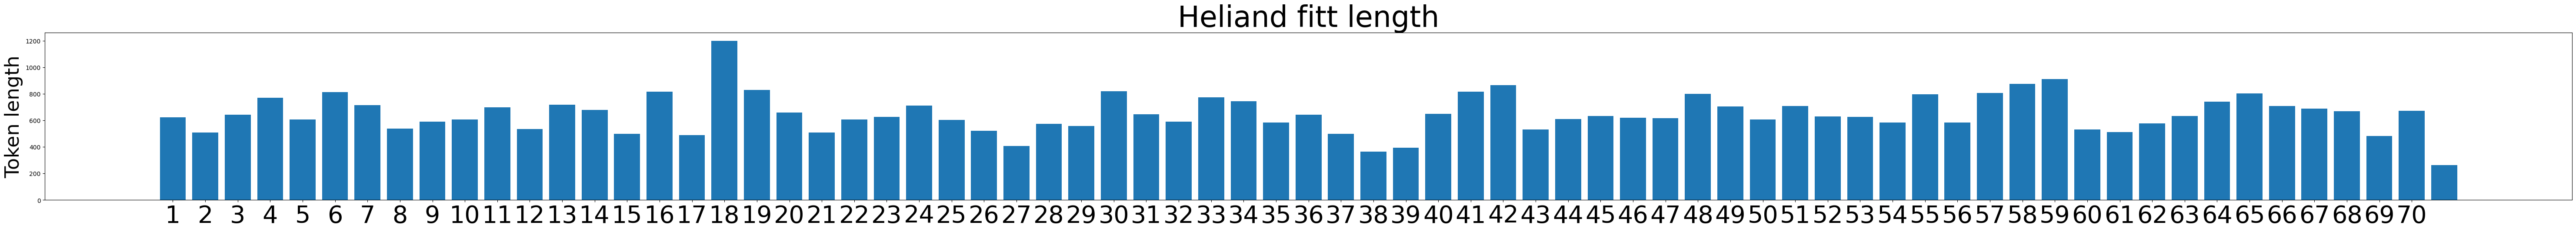

In [9]:
fig, ax = plt.subplots(figsize=(75,5))
lengths = count_unit_lengths(fitt_division)
x = np.array(list(lengths.keys()))
y = np.array(list(lengths.values()))
ax.bar(x,y)
plt.xticks(range(1,71), fontsize='40')
plt.xticks(fontsize='40')
ax.set_title('Heliand fitt length', fontsize='48')
ax.set_ylabel('Token length', fontsize='32')
plt.savefig(fname='fitt-length.svg', format='svg', bbox_inches='tight')
plt.show()

A more interesting question is whether these fitts differ in their lexical diversity, as that would be a likely indicator of mixed authorship. Since lexical diversity requires chunks of equal length in order to be meaningful, we'll expend quite a few lines of code here just to be able to identify which fitts are represented in any given chunk of tokens from the poem as a whole:

In [10]:
text = dict()
section_list = list(fitt_division.keys())
for index,section in enumerate(section_list):
    if section == section_list[-1]:
        text[section] = [token['lemma'] for token in c_data[fitt_division[section]:]]
    else:
        next = section_list[index+1]
        text[section] = [token['lemma'] for token in c_data[fitt_division[section]:fitt_division[next]]]


In [24]:
chunk_size = 200
reverse_index = {v: k for k, v in fitt_division.items()}
def index_to_identifiers(needle, haystack=list(fitt_division.values())):
    pos_start = bisect_left(haystack, needle)
    pos_end = bisect_left(haystack, needle+chunk_size)
    if pos_start == 0:
        start = reverse_index[haystack[0]]
        end = reverse_index[haystack[pos_end - 1]]
    else:
        start = reverse_index[haystack[pos_start - 1]]
        end = reverse_index[haystack[pos_end - 1]]
    
    if start == end:
        return str(start)
    else:
        return str(start) + '–' + str(end)

In [25]:
test = index_to_identifiers(36000)
print(test)

56–57


In [26]:
chunks = dict()
index_counter = 0
while index_counter < len(c_data):
    current_index = index_counter
    if len(c_data)-current_index < chunk_size:
        chunk = [token['lemma'] for token in c_data[current_index:]]
    else:
        chunk = [token['lemma'] for token in c_data[current_index:current_index+chunk_size]]
        chunks[current_index] = (index_to_identifiers(current_index), chunk)
    index_counter = current_index + chunk_size
current_index = len(c_data) - (len(c_data) % chunk_size) -1
remnant = [token['lemma'] for token in c_data[current_index:]]
chunks[current_index] = (index_to_identifiers(current_index), remnant)

In [27]:
ld = list()

for chunk in chunks.values():
    lex = LexicalRichness(chunk[1], preprocessor=None, tokenizer=None)
    ld.append((chunk[0], lex.ttr))

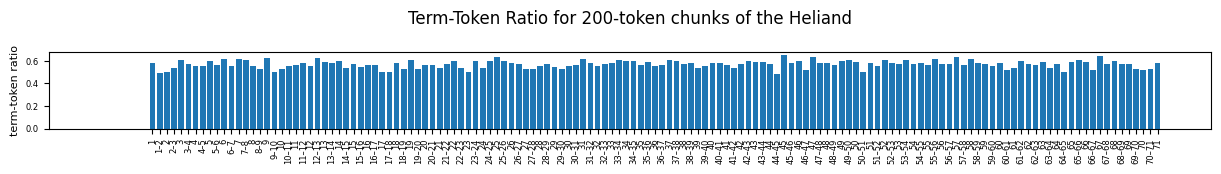

In [28]:
fig, ax = plt.subplots(figsize=(15,1))
x = [p[0] for p in ld]
y = [p[1] for p in ld]
ax.bar(x,y, lw=.1, zorder = 0)
ax.set_ylabel('term-token ratio', fontsize='8')
ax.set_title('Term-Token Ratio for ' + str(chunk_size) + '-token chunks of the Heliand', fontsize='12', pad='20')
plt.xticks(rotation='vertical')
rcParams['hatch.linewidth'] = 4
ax.tick_params(axis='both', which='major', labelsize=6)
#plt.subplots_adjust(wspace=0.8)
set_xmargin(ax, left=0.1, right=0.05)
plt.savefig(fname='ttr.svg', format='svg', bbox_inches='tight')
plt.show()


We're seeing a very even token-term ratio, whether we set the chunk size to 200 or 1000 tokens, so the assumption of single authorship is likely correct.

Now for cosine similarity. We'll start with TF-IDF, which measures for each lemma (in our case) how striking its frequency in a given fitt is in view of what proportion of the other fitts contains it. The similarity between any two fitts is then arrived at by calculating the dot product of the two arrays of TF-IDF values, i.e. we multiply the pair of TF-IDF scores for each term for two fitts, and then we sum all those products to find the cosine similarity score.

In [16]:
c_token_strings = dict()
for _fitt_no, _fitt_start in fitt_division.items():
    if _fitt_no + 1 in fitt_division:
        c_token_strings[_fitt_no] = ' '.join(token['form'] for token in c_data[_fitt_start:fitt_division[_fitt_no+1]])
    else:
        c_token_strings[_fitt_no] = ' '.join(token['form'] for token in c_data[_fitt_start:])

c_lemma_strings = dict()
for _fitt_no, _fitt_start in fitt_division.items():
    if _fitt_no + 1 in fitt_division:
        c_lemma_strings[_fitt_no] = ' '.join(token['lemma'] for token in c_data[_fitt_start:fitt_division[_fitt_no+1]])
    else:
        c_lemma_strings[_fitt_no] = ' '.join(token['lemma'] for token in c_data[_fitt_start:])

In [17]:
c_token_strings[50][:200]

'thuo uuarth thar so managon man muod after criste gihuorban hugiscefti sithor sia is helagun uuerc selƀon gisauuun huand gio er sulic ni uuarth uundar an uueroldi thann uuas eft thes uuerodes so filo '

In [18]:
vectorizer = TfidfVectorizer(min_df=1, max_df=0.7)
model = vectorizer.fit_transform(c_lemma_strings.values())
df = pd.DataFrame(cosine_similarity(model), fitt_division.keys(), fitt_division.keys())
df

,1,2,3,4,5,6,7,8,9,10,...,62,63,64,65,66,67,68,69,70,71
1,1.000000,0.083680,0.195637,0.119731,0.158875,0.190285,0.149904,0.103132,0.133406,0.151645,...,0.118846,0.150294,0.153218,0.137079,0.125773,0.104275,0.094166,0.053549,0.089984,0.065726
2,0.083680,1.000000,0.174337,0.131924,0.074138,0.220989,0.070678,0.078343,0.099312,0.124864,...,0.058237,0.051185,0.084007,0.074359,0.222559,0.062288,0.055273,0.087958,0.076527,0.060922
3,0.195637,0.174337,1.000000,0.174774,0.151831,0.276293,0.209451,0.146179,0.151816,0.226179,...,0.128527,0.099554,0.105771,0.113307,0.136361,0.100503,0.124215,0.102293,0.135510,0.093021
4,0.119731,0.131924,0.174774,1.000000,0.255586,0.515049,0.081286,0.110386,0.232912,0.272764,...,0.086264,0.081112,0.075561,0.275734,0.187009,0.179678,0.269619,0.425616,0.521706,0.245566
5,0.158875,0.074138,0.151831,0.255586,1.000000,0.250706,0.236152,0.194231,0.253590,0.173356,...,0.124428,0.105848,0.136596,0.124919,0.124380,0.127433,0.149434,0.181202,0.138346,0.108908
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,0.104275,0.062288,0.100503,0.179678,0.127433,0.200891,0.116505,0.123408,0.150689,0.115347,...,0.135069,0.200914,0.198018,0.246021,0.279290,1.000000,0.274202,0.207263,0.213029,0.141852
68,0.094166,0.055273,0.124215,0.269619,0.149434,0.217725,0.093646,0.089315,0.113700,0.151599,...,0.141326,0.120971,0.150119,0.191949,0.187837,0.274202,1.000000,0.438014,0.440136,0.135882
69,0.053549,0.087958,0.102293,0.425616,0.181202,0.342542,0.074238,0.116783,0.154622,0.156130,...,0.125892,0.111825,0.108182,0.240533,0.231667,0.207263,0.438014,1.000000,0.515583,0.270618
70,0.089984,0.076527,0.135510,0.521706,0.138346,0.383142,0.089759,0.094375,0.142928,0.208273,...,0.116523,0.088644,0.127236,0.292349,0.204913,0.213029,0.440136,0.515583,1.000000,0.274570


The similarity matrix tells you for each fit what the similarity score to each of the othher fitts is, expressed as a float between 0 and 1. But it may be more intuitive to visualize these data as a scatter plot, to which end we'll reduce the many dimensions of our data to two or three:

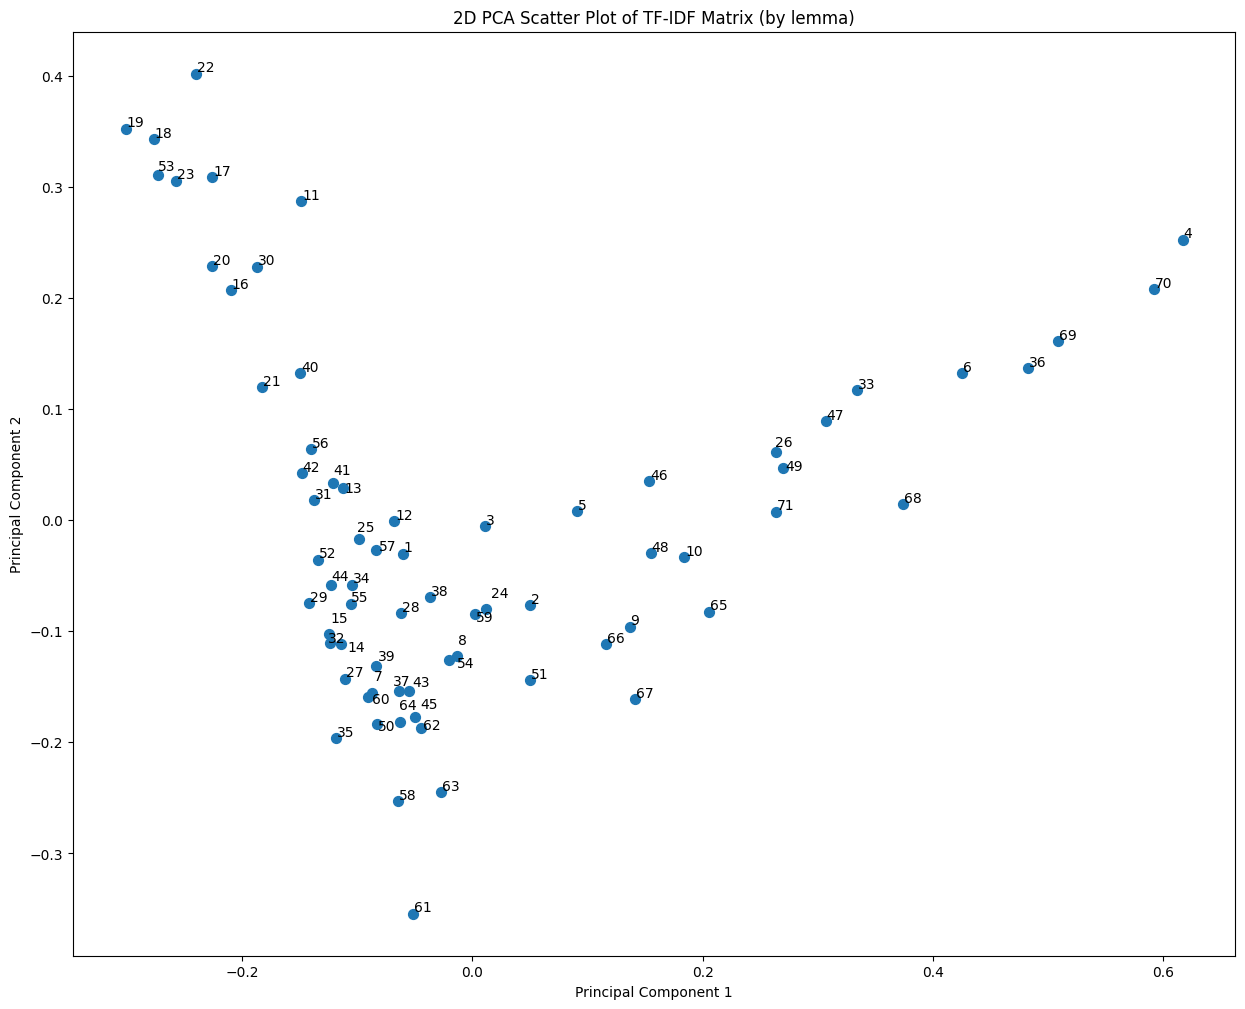

In [19]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(model.toarray())
plt.figure(figsize=(15, 12))
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=50)
labels = [plt.annotate(i, (pca_result[i-1, 0], pca_result[i-1, 1])) for i in fitt_division]
adjust_text(labels)
plt.title('2D PCA Scatter Plot of TF-IDF Matrix (by lemma)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.savefig(fname='tfidf.svg', format='svg', bbox_inches='tight')
plt.show()

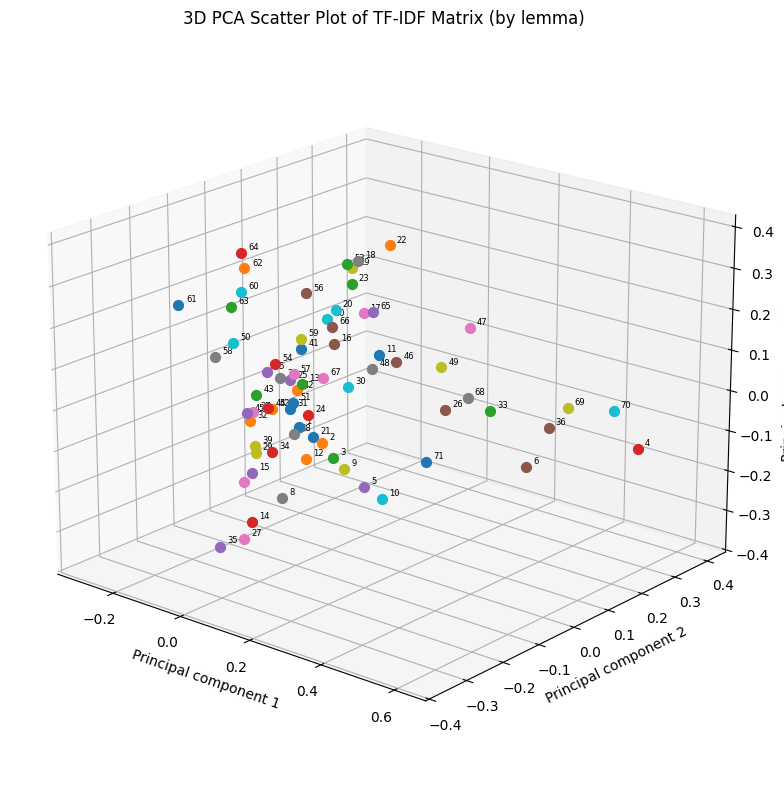

In [20]:
pca3d = PCA(n_components=3)
pca3d_result = pca3d.fit_transform(model.toarray())
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')
x = pca3d_result[:, 0]
y = pca3d_result[:, 1]
z = pca3d_result[:, 2]
ax.set_title('3D PCA Scatter Plot of TF-IDF Matrix (by lemma)', fontsize='12')
ax.set_xlabel('Principal component 1')
ax.set_ylabel('Principal component 2')
ax.set_zlabel('Principal component 3')
ax.view_init(elev=20, azim=310)
plt.tight_layout()
for i in fitt_division:
    ax.scatter(x[i-1],y[i-1],z[i-1], s=50)
    ax.text(x[i-1],y[i-1]+0.02,z[i-1], i, fontsize=6)
plt.savefig(fname='tfidf3d.svg', format='svg', bbox_inches='tight')
plt.show()


What we're seeing here is that there is dispersion, but no real clustering. Since we used PCA to reduce our dimensions to two and three, we might be able to use that model further to optimize our data for clustering, but I'm going to leave that for now.

What we can at least say from these data is that there is a triangular distribution, with extremes represented by the clusters (4, 70), (18, 19, 22), and (58, 61, 63). Since we've used lemmas, not token forms, as input data, those differences must be explained by either subject matter or else diction (e.g. using other words for similar concepts); they cannot be explained by orthographical differences, as is usually the case with medieval corpora when we have no access to lemmatized data.

Next, we can apply the Word2Vec model, using its Doc2Vec implementation to compare whole fitts. This goes beyond statistics to yield insight into the modelled meaning of words, and so it tries to distinguish documents by what they are about.

In [21]:
num_cores = multiprocessing.cpu_count()
data = c_lemma_strings
tagged_data = [TaggedDocument(words=v, tags=[k]) for k,v in data.items()]
model = Doc2Vec(
    vector_size=20, 
    min_count=2, 
    epochs=50, 
    workers=num_cores, 
    dm=1,               # DM is more context-sensitive, PV-DBOW is more efficient;
    dbow_words=0)       # experiment with both, but expect better results with dm=1
model.build_vocab(tagged_data)
model.train(tagged_data, total_examples=model.corpus_count, epochs=model.epochs)

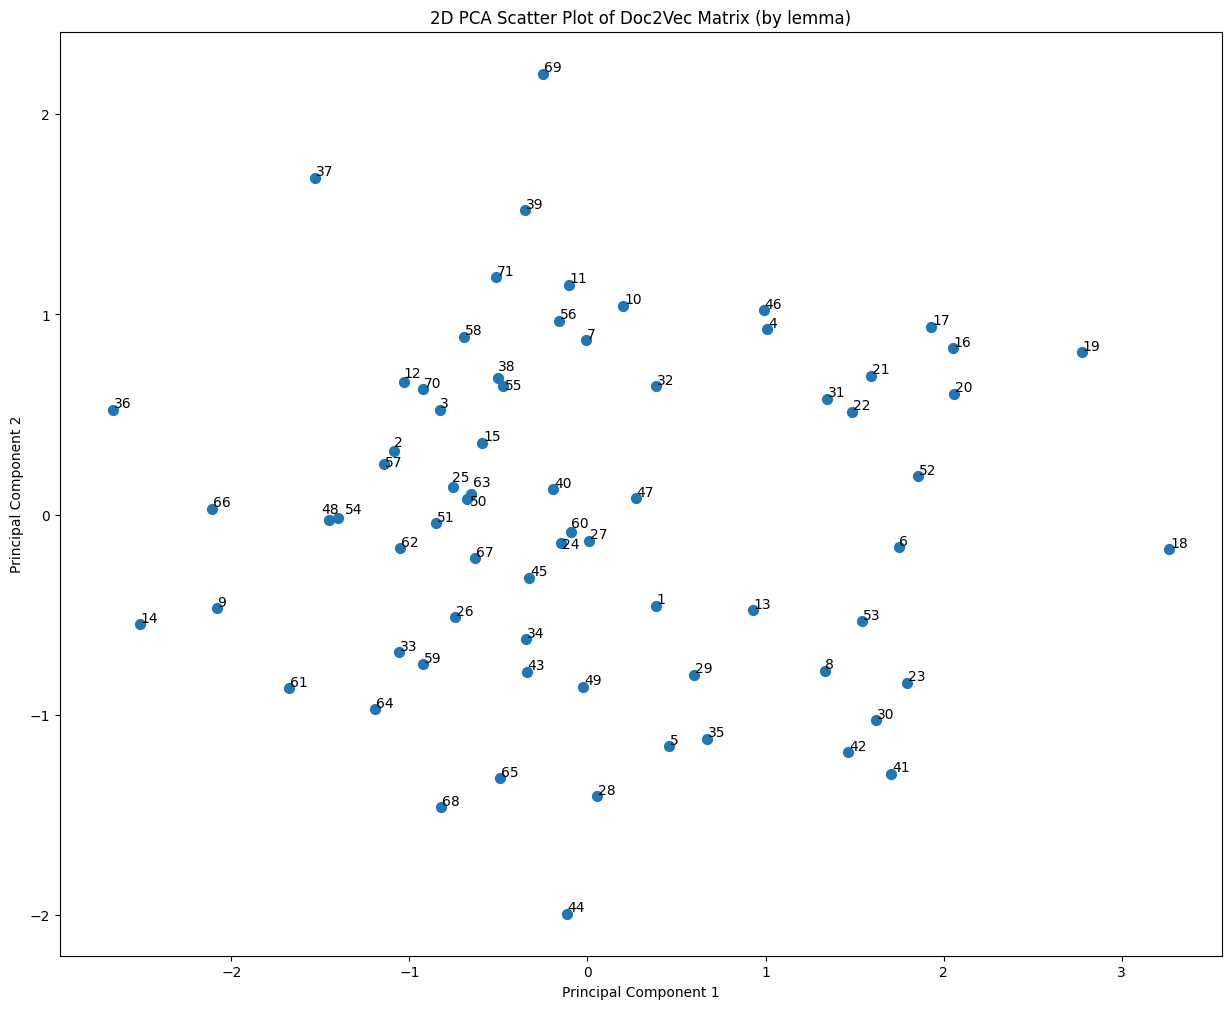

In [22]:
pca = PCA(n_components=2)
vectors = np.array([model.dv[i] for i in data.keys()])
pca_result = pca.fit_transform(vectors)
plt.figure(figsize=(15, 12))
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=50)
labels = [plt.annotate(i, (pca_result[i-1, 0], pca_result[i-1, 1])) for i in fitt_division]
adjust_text(labels)
plt.title('2D PCA Scatter Plot of Doc2Vec Matrix (by lemma)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.savefig(fname='doc2vec.svg', format='svg', bbox_inches='tight')
plt.show()

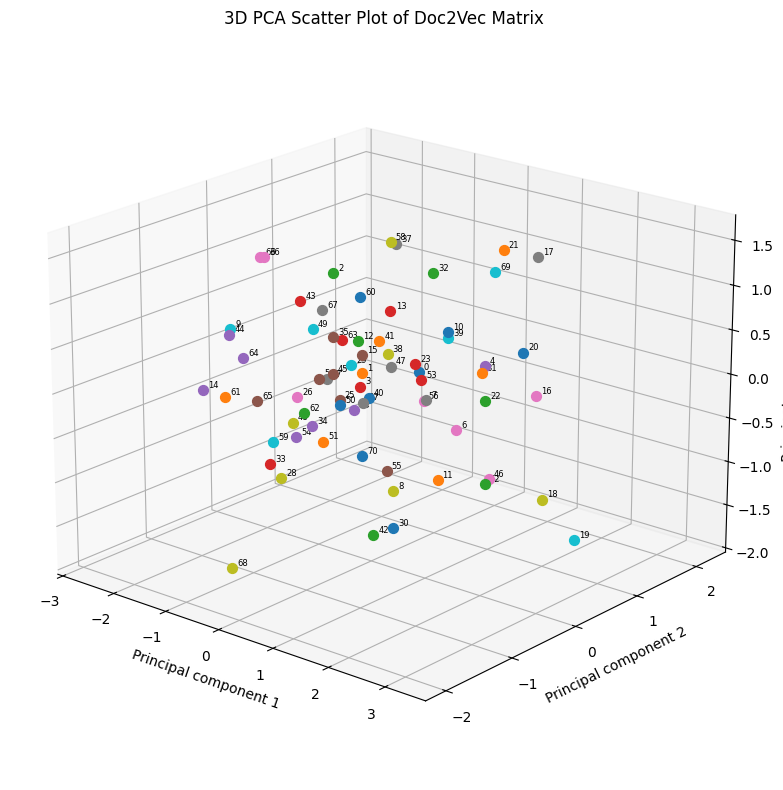

In [23]:
pca3d = PCA(n_components=3)
vectors = np.array([model.dv[i] for i in data.keys()])
pca_result = pca3d.fit_transform(vectors)
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')
x = pca_result[:, 0]
y = pca_result[:, 1]
z = pca_result[:, 2]
ax.set_title('3D PCA Scatter Plot of Doc2Vec Matrix', fontsize='12')
ax.set_xlabel('Principal component 1')
ax.set_ylabel('Principal component 2')
ax.set_zlabel('Principal component 3')
ax.view_init(elev=20, azim=310)
plt.tight_layout()
for i, txt in enumerate(data.keys()):
    ax.scatter(x[i-1],y[i-1],z[i-1], s=50)
    ax.text(x[i-1],y[i-1]+0.08,z[i-1], i, fontsize=6)
plt.savefig(fname='doc2vec3d.svg', format='svg', bbox_inches='tight')
plt.show()


Even going off lemma data as opposed to token forms, Doc2Vec yields a different distribution than TF-IDF. All the extremes here are represented by different fitts than in the TF-IDF model. In both cases, of course, one could take these data as a starting point to compare the extremes to try and explain what makes them so different, or study clusters to see what they have in common.